# Initial Model Tuning

In [18]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

with open('../data/processed_graphs.pkl', 'rb') as f:
    save_data = pickle.load(f)

split_datasets = save_data['split_datasets']
thresholds = save_data['thresholds']

# Normalize ages using training set stats
train_ages = [g.y.item() for g in split_datasets[0.3]['train']]
age_mean = np.mean(train_ages)
age_std = np.std(train_ages)

for t in thresholds:
    for split in ['train', 'val', 'test']:
        for g in split_datasets[t][split]:
            g.y = torch.tensor([(g.y.item() - age_mean) / age_std], dtype=torch.float)

# Verify clean data
nan_count = sum(1 for g in split_datasets[0.3]['train'] if torch.isnan(g.x).any())
print(f'NaN graphs: {nan_count}')
print(f'Age normalized — mean: {age_mean:.2f}, std: {age_std:.2f}')

NaN graphs: 0
Age normalized — mean: 16.68, std: 6.97


We load the processed graphs and normalize the target ages using z-score standardization computed from the training set only. This prevents the raw age values (6–56) from causing exploding losses during training, while avoiding data leakage since val/test are scaled using training stats

In [19]:
class BrainAgeGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        
        # 2 graph convolution layers with batch normalization
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        
        # Output layer — maps pooled graph embedding to single age prediction
        self.fc = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, data):
        # Clone inputs to prevent in-place corruption of original data
        x = data.x.clone()
        edge_index = data.edge_index.clone()
        batch = data.batch
        
        # Graph convolution layers
        x = self.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.relu(self.bn2(self.conv2(x, edge_index)))
        
        # Pool all node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        
        return x.squeeze()


The model uses 2 GCN layers with BatchNorm for stability, followed by global mean pooling to summarize all 200 node embeddings into a single graph-level vector, and a linear layer to predict age.

In [20]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        # Clip gradients to prevent exploding values
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    # No gradient tracking needed for evaluation
    with torch.no_grad():
        for batch in loader:
            pred = model(batch)
            loss = loss_fn(pred, batch.y)
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

### Edge Correlation Threshold of 0

In [21]:
# Training with no edge weight threshold

model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_loader = DataLoader(split_datasets[0.0]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.0]['val'], batch_size=8)

train_losses = []
val_losses = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.5453 | Val Loss: 0.8039
Epoch  20 | Train Loss: 0.3956 | Val Loss: 0.8648
Epoch  30 | Train Loss: 0.3262 | Val Loss: 0.8552
Epoch  40 | Train Loss: 0.1985 | Val Loss: 0.8994
Epoch  50 | Train Loss: 0.2857 | Val Loss: 0.6367
Epoch  60 | Train Loss: 0.2674 | Val Loss: 0.6809
Epoch  70 | Train Loss: 0.2254 | Val Loss: 1.3065
Epoch  80 | Train Loss: 0.2379 | Val Loss: 0.7559
Epoch  90 | Train Loss: 0.2159 | Val Loss: 0.7291
Epoch 100 | Train Loss: 0.2249 | Val Loss: 0.7331


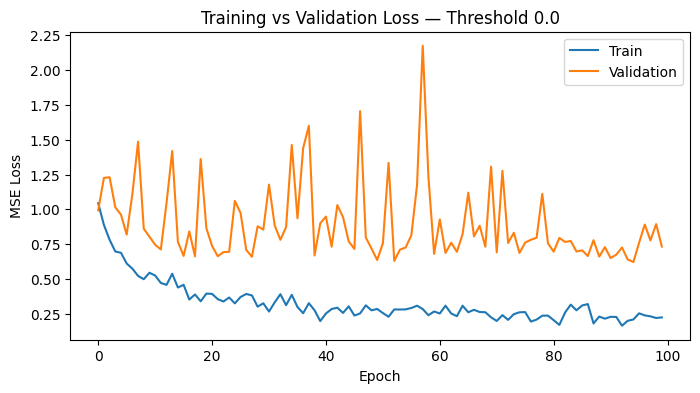

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.0')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.2

In [23]:
# Training with edge weight threshold of 0.2
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_loader = DataLoader(split_datasets[0.2]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.2]['val'], batch_size=8)

train_losses_02 = []
val_losses_02 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_02.append(train_loss)
    val_losses_02.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.3864 | Val Loss: 0.9076
Epoch  20 | Train Loss: 0.2843 | Val Loss: 0.7715
Epoch  30 | Train Loss: 0.2602 | Val Loss: 0.7281
Epoch  40 | Train Loss: 0.2192 | Val Loss: 0.7140
Epoch  50 | Train Loss: 0.1738 | Val Loss: 0.8223
Epoch  60 | Train Loss: 0.2165 | Val Loss: 1.1127
Epoch  70 | Train Loss: 0.1610 | Val Loss: 0.8794
Epoch  80 | Train Loss: 0.1797 | Val Loss: 0.7184
Epoch  90 | Train Loss: 0.2439 | Val Loss: 0.6875
Epoch 100 | Train Loss: 0.1841 | Val Loss: 0.6346


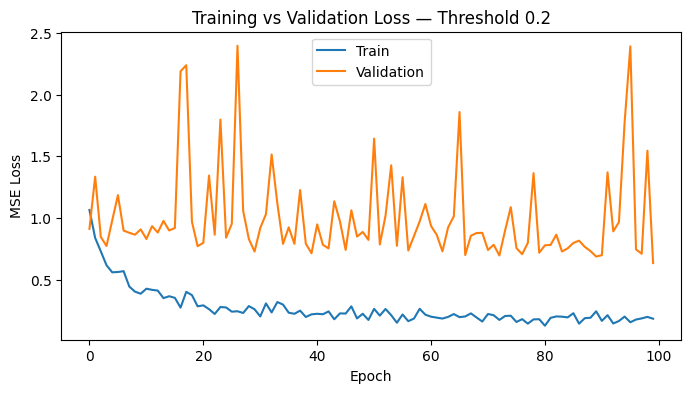

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_02, label='Train')
plt.plot(val_losses_02, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.2')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.3

In [25]:
# Training with edge weight threshold of 0.3
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_loader = DataLoader(split_datasets[0.3]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.3]['val'], batch_size=8)

train_losses_03 = []
val_losses_03 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_03.append(train_loss)
    val_losses_03.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        

Epoch  10 | Train Loss: 0.3326 | Val Loss: 0.7766
Epoch  20 | Train Loss: 0.2707 | Val Loss: 1.0878
Epoch  30 | Train Loss: 0.1897 | Val Loss: 0.8781
Epoch  40 | Train Loss: 0.1718 | Val Loss: 0.7992
Epoch  50 | Train Loss: 0.1475 | Val Loss: 0.6821
Epoch  60 | Train Loss: 0.2248 | Val Loss: 0.8671
Epoch  70 | Train Loss: 0.1689 | Val Loss: 0.7232
Epoch  80 | Train Loss: 0.1539 | Val Loss: 0.6991
Epoch  90 | Train Loss: 0.1147 | Val Loss: 0.7315
Epoch 100 | Train Loss: 0.1548 | Val Loss: 0.7682


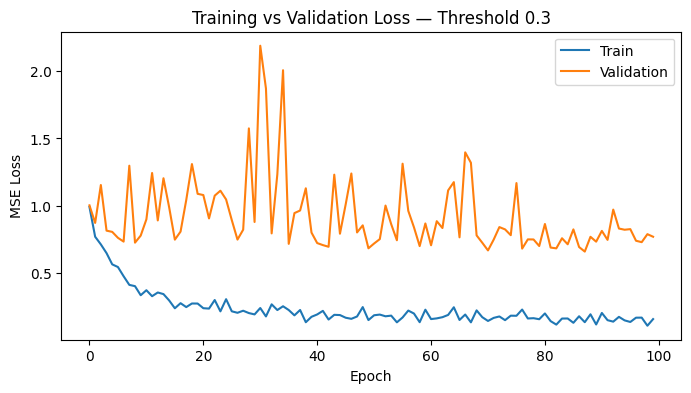

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_03, label='Train')
plt.plot(val_losses_03, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.3')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.4

In [27]:
# Training with edge weight threshold of 0.4
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_loader = DataLoader(split_datasets[0.4]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.4]['val'], batch_size=8)

train_losses_04 = []
val_losses_04 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_04.append(train_loss)
    val_losses_04.append(val_loss)
    


    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.2808 | Val Loss: 1.0797
Epoch  20 | Train Loss: 0.2009 | Val Loss: 0.6829
Epoch  30 | Train Loss: 0.1762 | Val Loss: 0.8967
Epoch  40 | Train Loss: 0.1737 | Val Loss: 0.6204
Epoch  50 | Train Loss: 0.1893 | Val Loss: 0.7951
Epoch  60 | Train Loss: 0.1569 | Val Loss: 0.8370
Epoch  70 | Train Loss: 0.1007 | Val Loss: 0.6539
Epoch  80 | Train Loss: 0.1407 | Val Loss: 0.8882
Epoch  90 | Train Loss: 0.1099 | Val Loss: 1.0019
Epoch 100 | Train Loss: 0.1901 | Val Loss: 0.7399


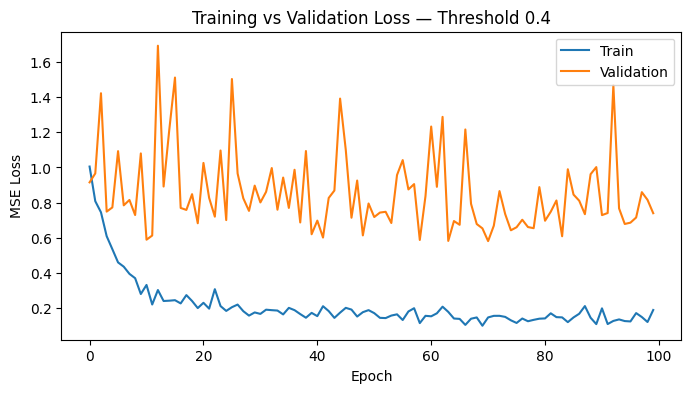

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_04, label='Train')
plt.plot(val_losses_04, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.4')
plt.legend()
plt.show()

In [29]:
import pandas as pd

results = {
    'Threshold': [0.0, 0.2, 0.3, 0.4],
    'Final Train Loss': [train_losses[-1], train_losses_02[-1], train_losses_03[-1], train_losses_04[-1]],
    'Best Val Loss': [min(val_losses), min(val_losses_02), min(val_losses_03), min(val_losses_04)],
    'Final Val Loss': [val_losses[-1], val_losses_02[-1], val_losses_03[-1], val_losses_04[-1]],
    'Val Loss Std': [np.std(val_losses), np.std(val_losses_02), np.std(val_losses_03), np.std(val_losses_04)],
    'Edges (per subject)': [39800, 17432, 9450, 4516]
}

comparison = pd.DataFrame(results)
comparison = comparison.round(4)
print(comparison.to_string(index=False))

 Threshold  Final Train Loss  Best Val Loss  Final Val Loss  Val Loss Std  Edges (per subject)
       0.0            0.2249         0.6219          0.7331        0.2710                39800
       0.2            0.1841         0.6346          0.6346        0.3670                17432
       0.3            0.1548         0.6577          0.7682        0.2752                 9450
       0.4            0.1901         0.5815          0.7399        0.2250                 4516


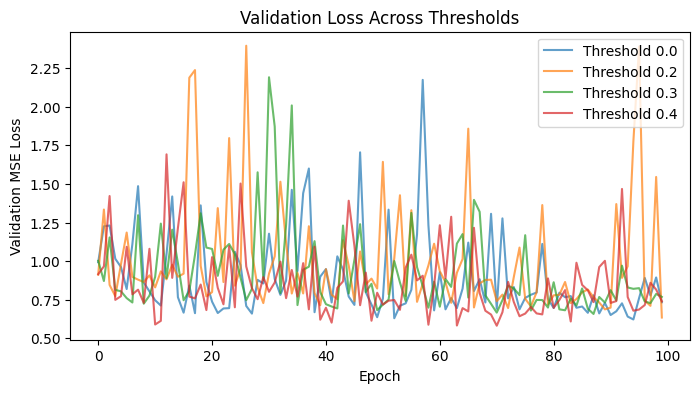

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(val_losses, label='Threshold 0.0', alpha=0.7)
plt.plot(val_losses_02, label='Threshold 0.2', alpha=0.7)
plt.plot(val_losses_03, label='Threshold 0.3', alpha=0.7)
plt.plot(val_losses_04, label='Threshold 0.4', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE Loss')
plt.title('Validation Loss Across Thresholds')
plt.legend()
plt.show()